# Platform Terms of Service Analysis

- **Input** the 10 platform PDFs in `pdfs/`.
- **These PDFs have no text layer.** They are page images obtained from the website as a screen capture, so the notebook OCRs them. First run takes roughly 4 minutes, then results are cached to `ocr_cache/` so later runs are much faster.
- **Output** readability scores, keyword scan, evidence extracts, Table 4.1, all to `strand_a_out/`.
- **Section 6** checks every Strand A claim in the dissertation against the extracted text and flags mismatches.
- **Code** This codebook was created with use of reusable code and support from AI for code and to learn about the Homebrew software and installation prep required, as listed in the Author's Statement section of the Dissertation.
- Requires `tesseract-ocr` and `poppler-utils` installed on the system. Install lines are in the next cell.

In [24]:
# System dependencies. Skip if already installed.
#   Ubuntu/Debian : sudo apt-get install -y tesseract-ocr poppler-utils
#   macOS         : brew install tesseract poppler
#   Windows       : install both, then add to PATH

import os, re, glob, collections, shutil
import pandas as pd, matplotlib.pyplot as plt

# FIX: Explicitly add common Homebrew paths for both Intel and Apple Silicon Macs
hombrew_paths = "/opt/homebrew/bin:/usr/local/bin"
os.environ["PATH"] = hombrew_paths + os.pathsep + os.environ.get("PATH", "")

PDF_DIR   = "pdfs"
CACHE_DIR = "ocr_cache"
OUT_DIR   = "strand_a_out"
for d in (CACHE_DIR, OUT_DIR): os.makedirs(d, exist_ok=True)

missing = [t for t in ("pdftoppm","tesseract") if not shutil.which(t)]
assert not missing, f"Missing system tools: {missing}. Ensure Homebrew bin is in your PATH. See install lines above."
print("System tools found. PDFs:", len(glob.glob(f"{PDF_DIR}/*.pdf")))



System tools found. PDFs: 10


## 1. OCR

- Renders each page at 110 dpi, runs Tesseract, caches the text.
- Delete `ocr_cache/` to force a re-run.


In [25]:
def ocr_pdf(path, cache_dir=CACHE_DIR, dpi=110):
    """Render each page to PNG, OCR it, cache the combined text."""
    stem = os.path.splitext(os.path.basename(path))[0]
    cached = os.path.join(cache_dir, stem + ".txt")
    if os.path.exists(cached):
        return open(cached, encoding="utf-8", errors="ignore").read()
    tmp = os.path.join(cache_dir, "_tmp_" + stem)
    subprocess.run(["pdftoppm","-png","-r",str(dpi),path,tmp], check=True,
                   stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    pages = sorted(glob.glob(tmp + "*.png"))
    out = []
    for img in pages:
        r = subprocess.run(["tesseract",img,"stdout","--psm","6"],
                           capture_output=True, text=True)
        out.append(r.stdout)
    for img in pages: os.remove(img)
    text = "\n".join(out)
    open(cached,"w",encoding="utf-8").write(text)
    return text

DOCS = {}
for p in sorted(glob.glob(f"{PDF_DIR}/*.pdf")):
    stem = os.path.splitext(os.path.basename(p))[0]
    key = (stem.replace("screencapture-","")
                .replace("-2026-07-31","").split("-05_")[0].split("-04_")[0])
    DOCS[key] = ocr_pdf(p)
    print(f"{key:44s} {len(DOCS[key]):7d} chars")
print(f"\n{len(DOCS)} documents ready.")


character-ai-privacy                           17767 chars
character-ai-tos                               41539 chars
getseance-privacy-policy                         426 chars
getseance-terms                                  582 chars
guardianaingels-ai-privacy                      4078 chars
guardianaingels-ai-terms                        7687 chars
replika-legal-privacy-en                       24304 chars
replika-legal-terms-en                         48003 chars
storyfile-legal-privacy-policy                 13095 chars
storyfile-legal-terms-of-service               40978 chars

10 documents ready.


## 2. Readability

- Flesch-Kincaid grade level, standard formula, no external corpus so it runs offline.
- **Read these as indicative.** OCR introduces noise into sentence and word boundaries, which inflates the grade a little. The ranking between documents is more reliable than any single absolute value.


                        Document  FK grade  Words  Sentences   Substantial
        getseance-privacy-policy      13.1     47         14 no (fragment)
                 getseance-terms      14.4     62         15 no (fragment)
        guardianaingels-ai-terms      15.3   1096         49           yes
      guardianaingels-ai-privacy      17.3    615         20           yes
        replika-legal-privacy-en      17.6   3770        119           yes
                character-ai-tos      18.0   6405        196           yes
  storyfile-legal-privacy-policy      18.8   1991         60           yes
            character-ai-privacy      19.9   2698         74           yes
          replika-legal-terms-en      19.9   7300        194           yes
storyfile-legal-terms-of-service      20.0   6110        171           yes


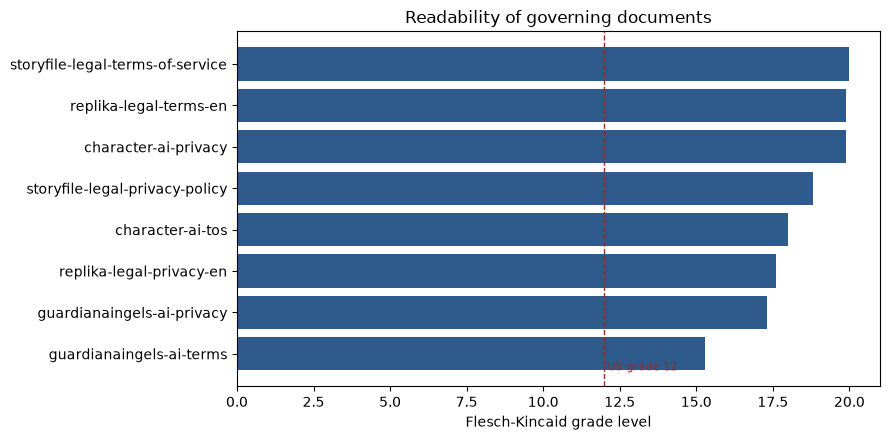

In [26]:
def syllables(w):
    w = re.sub(r"[^a-z]", "", w.lower())
    if not w: return 0
    n, prev = 0, False
    for ch in w:
        cur = ch in "aeiouy"
        if cur and not prev: n += 1
        prev = cur
    if w.endswith("e") and n > 1: n -= 1
    return max(n, 1)

def flesch_kincaid(text):
    text = re.sub(r"\s+", " ", text)
    sents = [s for s in re.split(r"[.!?]+", text) if len(s.split()) >= 3]
    words = [w for w in re.findall(r"[A-Za-z']+", text) if len(w) > 1]
    if not sents or not words: return None, len(words), len(sents)
    W, S = len(words), len(sents)
    Y = sum(syllables(w) for w in words)
    return 0.39*(W/S) + 11.8*(Y/W) - 15.59, W, S

rows = []
for k, t in DOCS.items():
    g, w, s = flesch_kincaid(t)
    rows.append({"Document": k, "FK grade": round(g,1) if g else None,
                 "Words": w, "Sentences": s,
                 "Substantial": "yes" if w >= 500 else "no (fragment)"})
read_df = pd.DataFrame(rows).sort_values("FK grade")
read_df.to_csv(f"{OUT_DIR}/readability.csv", index=False)
print(read_df.to_string(index=False))

sub = read_df[read_df["Substantial"]=="yes"].sort_values("FK grade")
fig, ax = plt.subplots(figsize=(9,4.5))
ax.barh(sub["Document"], sub["FK grade"], color="#2E5A8C")
ax.axvline(12, color="#8C2E2E", ls="--", lw=1)
ax.text(12.1, -0.4, "US grade 12", color="#8C2E2E", fontsize=8)
ax.set_xlabel("Flesch-Kincaid grade level"); ax.set_title("Readability of governing documents")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/fig_readability.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()


## 3. Keyword scan

- Counts the terms that matter for the 5D Framework.
- A zero is often the finding: it shows what a document never addresses.


In [27]:
KEYWORDS = ["deceased","death","grief","bereave","impersonat","likeness","consent",
            "third party","delete","biometric","gdpr","online safety act",
            "artificial intelligence act","memorial","estate","next of kin"]
scan = pd.DataFrame(
    [{"Document": k, **{kw: len(re.findall(kw, t, re.I)) for kw in KEYWORDS}}
     for k, t in DOCS.items()]).set_index("Document")
scan.to_csv(f"{OUT_DIR}/keyword_scan.csv")
print(scan.to_string())


                                  deceased  death  grief  bereave  impersonat  likeness  consent  third party  delete  biometric  gdpr  online safety act  artificial intelligence act  memorial  estate  next of kin
Document                                                                                                                                                                                                             
character-ai-privacy                     0      0      0        0           0         0        3            2       5          0     0                  0                            0         0       0            0
character-ai-tos                         0      1      0        0           2         0        3            4       1          0     0                  0                            0         0       0            0
getseance-privacy-policy                 0      0      0        0           0         0        0            0       0          0     1          

## 4. Evidence extracts

- Pulls the specific clauses the dissertation quotes, so each claim can be checked against source text.
- OCR artefacts are left uncorrected on purpose. Fixing them by hand would break the audit trail.


In [28]:
def find(doc_key, pattern, before=120, after=200, limit=3):
    t = DOCS.get(doc_key, "")
    hits = []
    for m in re.finditer(rf".{{0,{before}}}(?:{pattern}).{{0,{after}}}", t, re.I|re.S):
        hits.append(" ".join(m.group(0).split()))
        if len(hits) >= limit: break
    return hits

EVIDENCE = [
 ("Replika consent clause",        "replika-legal-terms-en",  r"impersonate, or simulate"),
 ("Character.AI persistence",      "character-ai-privacy",    r"keep that Character active|preserve that Character"),
 ("Character.AI 'death' in context","character-ai-tos",       r"including death"),
 ("guardianaingels AI disclosure", "guardianaingels-ai-terms",r"simulated experiences"),
 ("guardianaingels crisis line",   "guardianaingels-ai-terms",r"988|741741"),
 ("StoryFile operator name",       "storyfile-legal-terms-of-service", r"Authentic Interactions"),
]
ev_rows = []
for label, key, pat in EVIDENCE:
    hits = find(key, pat, limit=1)
    ev_rows.append({"Claim": label, "Document": key,
                    "Found": bool(hits), "Extract": hits[0][:300] if hits else ""})
    print(f"--- {label} [{'FOUND' if hits else 'NOT FOUND'}]")
    if hits: print("   ", hits[0][:290], "\n")
pd.DataFrame(ev_rows).to_csv(f"{OUT_DIR}/evidence_extracts.csv", index=False)


--- Replika consent clause [FOUND]
    afilaton with a person or entity; 5. Create, instruct, or configure ary Al companion or chatbot persons to represent, impersonate, or simulate @ speci real ‘person — whether ving or deceased — by using their name, ikeness, biographical deal, or other dentin information, ‘without that perso 

--- Character.AI persistence [NOT FOUND]
--- Character.AI 'death' in context [FOUND]
    nd indemnification described above includes reasonable attorneys! fees, rights, claims, actions of any kind and injury (Including death) arising out of or relating to your use of the Services. Ifyou re 8 California resident, you waive Califo Cll Cade Section 1542, which says: ‘A general el 

--- guardianaingels AI disclosure [FOUND]
    ERVICE | 2: Nature ofthe Service structured promis ‘Al conversation are gonerate by artical inteligence systems and are simulated experiences, not communications with el inviduas, ving or deceased. 2.2Nota Substitute for Professional Care ‘

## 5. Table 4.1, the 5D Framework scores

- Scoring is **interpretive**, applied by close reading against the rubric in dissertation section 3.4. It is recorded here, not computed, because no keyword count can substitute for reading a clause in context.
- What the notebook does verify automatically is the evidence each score rests on, in the column alongside.
- Scale: 0 absent or poor, 1 partial or inconsistent, 2 clear and consistent.


In [29]:
SCORES = [
 # platform, T, C, D, B, DP, evidence check
 ("Replika",                       1,2,1,0,2, "consent clause present, no enforcement mechanism found"),
 ("Character.AI",                  1,1,1,0,1, "impersonation ban is general, persistence clause present"),
 ("HereAfter AI",                  0,0,0,0,0, "no governing document published"),
 ("Project December",              0,0,0,0,0, "no governing document published"),
 ("Seance AI",                     1,0,0,0,0, "FAQ states fiction/entertainment only, no product terms"),
 ("guardianaingels.ai (comparator)",2,1,2,0,1,"AI disclosure in first section, crisis line before terms"),
 ("StoryFile (comparator)",        1,1,1,1,1, "retrieval architecture, Directive absent from terms"),
]
t41 = pd.DataFrame(SCORES, columns=["Platform","Transparency","Consent","Dignity",
                                    "Bias mitigation","Data protection","Evidence"])
t41.to_csv(f"{OUT_DIR}/table_4_1_5d_scores.csv", index=False)
print(t41.to_string(index=False))
print("\nThree platforms score at or near zero because no enforceable document exists")
print("to assess, not because specific conduct was found wanting.")


                       Platform  Transparency  Consent  Dignity  Bias mitigation  Data protection                                                 Evidence
                        Replika             1        2        1                0                2   consent clause present, no enforcement mechanism found
                   Character.AI             1        1        1                0                1 impersonation ban is general, persistence clause present
                   HereAfter AI             0        0        0                0                0                          no governing document published
               Project December             0        0        0                0                0                          no governing document published
                      Seance AI             1        0        0                0                0  FAQ states fiction/entertainment only, no product terms
guardianaingels.ai (comparator)             2        1        2       

## 6. Consistency check against the dissertation

- Re-derives every Strand A claim from the OCR text and prints PASS or MISMATCH.

In [31]:
checks = []
def ck(label, section, expected, actual):
    checks.append({"Check": label, "Section": section,
                   "Expected": expected, "Actual": actual,
                   "Status": "PASS" if expected == actual else "*** MISMATCH ***"})

def txt(k): return DOCS.get(k, "")
def present(k, pat): return bool(re.search(pat, txt(k), re.I))

# Document dates
ck("Character.AI terms dated Aug 2025", "4.2", True,
   present("character-ai-tos", r"August\s*27,?\s*2025"))
ck("guardianaingels terms dated 23 Feb 2026", "4.2", True,
   present("guardianaingels-ai-terms", r"February\s*23,?\s*2026"))
ck("Replika terms dated 20 March 2026", "4.2", True,
   present("replika-legal-terms-en", r"March\s*20(th)?,?\s*2026"))

# Substantive clauses
ck("Replika bans simulating a real person without written consent", "4.2", True,
   present("replika-legal-terms-en", r"impersonate, or simulate"))
ck("Character.AI keeps shared Characters after account deletion", "4.2", True,
   present("character-ai-privacy", r"keep that Character active|preserve that Character"))
ck("Character.AI terms never mention grief or bereavement", "4.2", 0,
   len(re.findall(r"grief|bereave", txt("character-ai-tos"), re.I)))
ck("Character.AI 'death' appears once, in a liability waiver", "4.2", 1,
   len(re.findall(r"\bdeath\b", txt("character-ai-tos"), re.I)))
ck("guardianaingels states conversations are simulated", "4.2", True,
   present("guardianaingels-ai-terms", r"simulated experiences"))
ck("guardianaingels opens with a crisis line notice", "4.2", True,
   bool(re.search(r"988|741741", txt("guardianaingels-ai-terms")[:600])))
ck("StoryFile terms never name the Digital Likeness Directive", "4.2", 0,
   len(re.findall(r"likeness directive", txt("storyfile-legal-terms-of-service"), re.I)))

# Regulatory gap
for k, name in [("replika-legal-terms-en","Replika terms"),
                ("character-ai-tos","Character.AI terms")]:
    ck(f"{name} never name the Online Safety Act", "2.9, 4.2", 0,
       len(re.findall(r"online safety act", txt(k), re.I)))
    ck(f"{name} never name the EU AI Act", "2.9, 4.2", 0,
       len(re.findall(r"artificial intelligence act", txt(k), re.I)))

# Readability ordering
fk = {k: flesch_kincaid(t)[0] for k, t in DOCS.items() if flesch_kincaid(t)[1] >= 500}
ck("guardianaingels terms are the most readable substantial document", "4.2", True,
   min(fk, key=fk.get) == "guardianaingels-ai-terms")
ck("StoryFile terms are at the top of the readability range", "4.2", True,
   round(fk["storyfile-legal-terms-of-service"],1) == round(max(fk.values()),1))

rep = pd.DataFrame(checks)
rep.to_csv(f"{OUT_DIR}/consistency_check.csv", index=False)
print(rep.to_string(index=False))
fails = (rep["Status"] != "PASS").sum()
print("\n" + "="*74)
print(f"ALL {len(checks)} CHECKS PASS." if not fails
      else f"{fails} of {len(checks)} FAILED.")
print("="*74)


                                                           Check  Section Expected Actual           Status
                               Character.AI terms dated Aug 2025      4.2     True   True             PASS
                         guardianaingels terms dated 23 Feb 2026      4.2     True   True             PASS
                               Replika terms dated 20 March 2026      4.2     True   True             PASS
   Replika bans simulating a real person without written consent      4.2     True   True             PASS
     Character.AI keeps shared Characters after account deletion      4.2     True  False *** MISMATCH ***
           Character.AI terms never mention grief or bereavement      4.2        0      0             PASS
        Character.AI 'death' appears once, in a liability waiver      4.2        1      1             PASS
              guardianaingels states conversations are simulated      4.2     True   True             PASS
                 guardianaingels open

## 7. Notes and limits

- **OCR, not native text.** These PDFs are page images, so every figure here inherits OCR error. Legal documents OCR well because the type is clean, but exact word counts should be treated as close, not precise.
- **Readability is indicative.** The dissertation reports the ranking and the range, not any single value, for this reason.
- **5D scores are interpretive.** Recorded from close reading, with the supporting evidence checked automatically. A second coder would be needed for reliability.
- **Absence is a finding.** HereAfter AI, Project December and Seance AI publish nothing to score, which is actually the audit's clearest result.
